In [1]:
import os, sys
import pandas as pd
# Main project root
repo_root = r"c:\Users\charl\NUFFTRR_Poisson"
os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from Tests.CPU.testing_helpers import (
    run_tests_pipeline,
    set_global_config,
    get_global_config,
    render_accuracy,
    render_runtime,
    render_table2_accuracy,
    render_table2_runtime,
    plot_accuracy_table1,
    plot_runtime_table1,
    plot_accuracy_table2,
    plot_runtime_table2,
    plot_accuracy_comparison,
    plot_runtime_comparison
)

# =============================================================================
# Domain & Solver Tolerances
# =============================================================================
R = 1.0
RAD_UNIF = 1
PROBLEM_TYPE = 0
CUSTOM_PROBLEM = None

TOL_NUFFT = 1e-10
MAXITER_NUFFT = 200
EPS_FINUFFT = 1e-15         # Clean 15-digit double precision (no warning messages)
PRECOND_SHIFT = 1e-8
KDE_OVERSAMPLE = 4
KDE_BANDWIDTH = 1.0
QUAD_RULE = 1
BC_CHOICE = 1

# =============================================================================
# Machine-Precision Base Values
# =============================================================================
BASE_MACHINE_PRECS = {
    "Unif-FFT": 0.0,
    "Unif-NUDFT": 1e-20,
    "Unif-NUFFT": 1e-20,
    "Fixed-jittered-NUDFT": 1e-20,
    "Fixed-jittered-NUFFT": 1e-20,
    "Fixed-stratified_rand-NUDFT": 1e-20,
    "Fixed-stratified_rand-NUFFT": 1e-20,
    "Fixed-rand-NUDFT": 1e-14,
    "Fixed-rand-NUFFT": 1e-12,
}

# =============================================================================
# Dedicated Lambda Tables for All 6 Independent Sweeps
# =============================================================================
LAMBDAS_6_SWEEPS = {
    # -------------------------------------------------------------------------
    # 3 Sweeps: Varying N (Fixed M = 32, 128, 512)
    # -------------------------------------------------------------------------
    "VaryN_M32": {
        **BASE_MACHINE_PRECS,
        "Fixed-clustered-NUDFT": {32: 1e-16, 64: 1e-12, 128: 1e-11, 256: 1e-12, 512: 1e-11},
        "Fixed-clustered-NUFFT": 1e-6,
        "Fixed-sine-NUDFT":      {32: 1e-16, 64: 1e-16, 128: 1e-12, 256: 1e-11, 512: 1e-08},
        "Fixed-sine-NUFFT":      {32: 1e-6, 64: 1e-12, 128: 5e-6, 256: 5e-5, 512: 1e-5},
    },
    "VaryN_M128": {
        **BASE_MACHINE_PRECS,
        "Fixed-clustered-NUDFT": {32: 1e-16, 64: 1e-12, 128: 1e-11, 256: 1e-12, 512: 1e-11},
        "Fixed-clustered-NUFFT": 1e-6,
        "Fixed-sine-NUDFT":      {32: 1e-16, 64: 1e-16, 128: 1e-12, 256: 1e-11, 512: 1e-08},
        "Fixed-sine-NUFFT":      {32: 1e-6, 64: 1e-12, 128: 5e-6, 256: 5e-5, 512: 1e-5},
    },
    "VaryN_M512": {
        **BASE_MACHINE_PRECS,
        "Fixed-clustered-NUDFT": {32: 1e-16, 64: 1e-12, 128: 1e-11, 256: 1e-12, 512: 1e-11},
        "Fixed-clustered-NUFFT": 1e-6,
        "Fixed-sine-NUDFT":      {32: 1e-16, 64: 1e-16, 128: 1e-12, 256: 1e-11, 512: 1e-08},
        "Fixed-sine-NUFFT":      {32: 1e-6, 64: 1e-12, 128: 5e-6, 256: 5e-5, 512: 1e-5},
    },

    # -------------------------------------------------------------------------
    # 3 Sweeps: Varying M (Fixed N = 32, 128, 512)
    # -------------------------------------------------------------------------
    "VaryM_N32": {
        **BASE_MACHINE_PRECS,
        "Fixed-clustered-NUDFT": 1e-16,
        "Fixed-clustered-NUFFT": 1e-6,
        "Fixed-sine-NUDFT":      1e-16,
        "Fixed-sine-NUFFT":      1e-6,
    },
    "VaryM_N128": {
        **BASE_MACHINE_PRECS,
        "Fixed-clustered-NUDFT": 1e-11,
        "Fixed-clustered-NUFFT": 1e-6,
        "Fixed-sine-NUDFT":      1e-12,
        "Fixed-sine-NUFFT":      5e-6,
    },
    "VaryM_N512": {
        **BASE_MACHINE_PRECS,
        "Fixed-clustered-NUDFT": 1e-11,
        "Fixed-clustered-NUFFT": 1e-6,
        "Fixed-sine-NUDFT":      1e-08,
        "Fixed-sine-NUFFT":      1e-05,
    },
}

# Apply global parameters
set_global_config(
    R=R,
    rad_unif=RAD_UNIF,
    tol_nufft=TOL_NUFFT,
    maxiter_nufft=MAXITER_NUFFT,
    eps_finufft=EPS_FINUFFT,
    precond_shift=PRECOND_SHIFT,
    kde_oversample=KDE_OVERSAMPLE,
    kde_bandwidth=KDE_BANDWIDTH,
    quad_rule=QUAD_RULE,
    BC_choice=BC_CHOICE,
    problem_type=PROBLEM_TYPE,
    custom_problem=CUSTOM_PROBLEM
)

N_vals_c = [32, 64, 128, 256, 512]
M_vals_c = [32, 64, 128, 256, 512]

FIXED_M_LIST = [32, 128, 512]
FIXED_N_LIST = [32, 128, 512]

MUTE_OUTPUT = True

METHODS_COMP = [
    dict(name="Unif-FFT", label="Uniform / FFT", azu_unif=2, mesh_kind="uniform", solver_azu_unif=2, use_nudft=None),
    dict(name="Unif-NUDFT", label="Uniform / NUDFT", azu_unif=2, mesh_kind="uniform", solver_azu_unif=1, use_nudft=True),
    dict(name="Unif-NUFFT", label="Uniform / NUFFT", azu_unif=2, mesh_kind="uniform", solver_azu_unif=1, use_nudft=False),
]
for kind in ("rand", "stratified_rand", "jittered", "clustered", "sine"):
    METHODS_COMP += [
        dict(name=f"Fixed-{kind}-NUDFT", label=f"Fixed {kind} / NUDFT", azu_unif=1, mesh_kind=kind, solver_azu_unif=1, use_nudft=True),
        dict(name=f"Fixed-{kind}-NUFFT", label=f"Fixed {kind} / NUFFT", azu_unif=1, mesh_kind=kind, solver_azu_unif=1, use_nudft=False),
    ]


c:\Users\charl\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# =============================================================================
# Run All 6 Sweeps With Their Dedicated Lambda Configurations
# =============================================================================
print("\nRunning Accuracy Comparisons Across All 6 Sweeps...")

df_cN_by_M = {}
for fixed_m in FIXED_M_LIST:
    sweep_table = LAMBDAS_6_SWEEPS[f"VaryN_M{fixed_m}"]
    df_cN_by_M[fixed_m] = run_tests_pipeline(
        N_vals_c,
        None,
        fixed_other=fixed_m,
        methods=METHODS_COMP,
        test_type="Accuracy_VaryN",
        reg_param=sweep_table,
        mute=MUTE_OUTPUT,
    )

df_cM_by_N = {}
for fixed_n in FIXED_N_LIST:
    sweep_table = LAMBDAS_6_SWEEPS[f"VaryM_N{fixed_n}"]
    df_cM_by_N[fixed_n] = run_tests_pipeline(
        None,
        M_vals_c,
        fixed_other=fixed_n,
        methods=METHODS_COMP,
        test_type="Accuracy_VaryM",
        reg_param=sweep_table,
        mute=MUTE_OUTPUT,
    )

print("Done.")



Running Accuracy Comparisons Across All 6 Sweeps...


Pipeline (Accuracy_VaryN):   0%|          | 0/13 [00:00<?, ?it/s, method=Unif-FFT]

Pipeline (Accuracy_VaryM): 100%|██████████| 13/13 [01:34<00:00,  7.29s/it, method=Fixed-sine-NUFFT]          

Done.


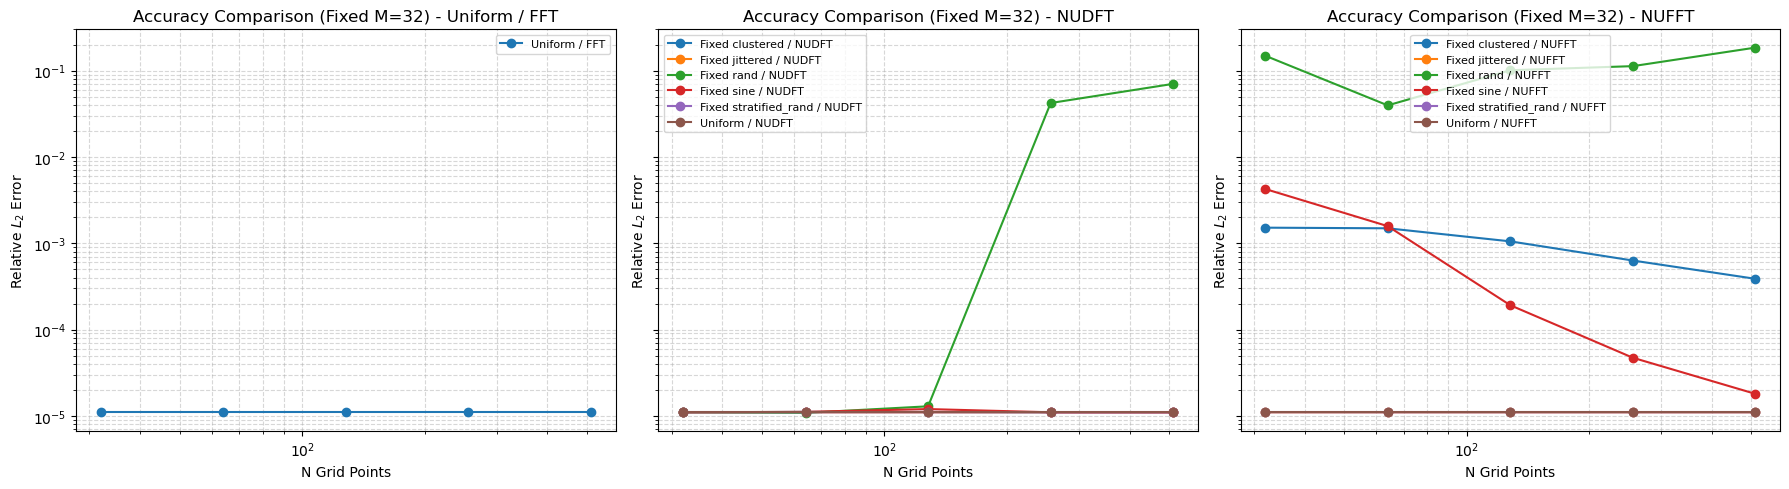

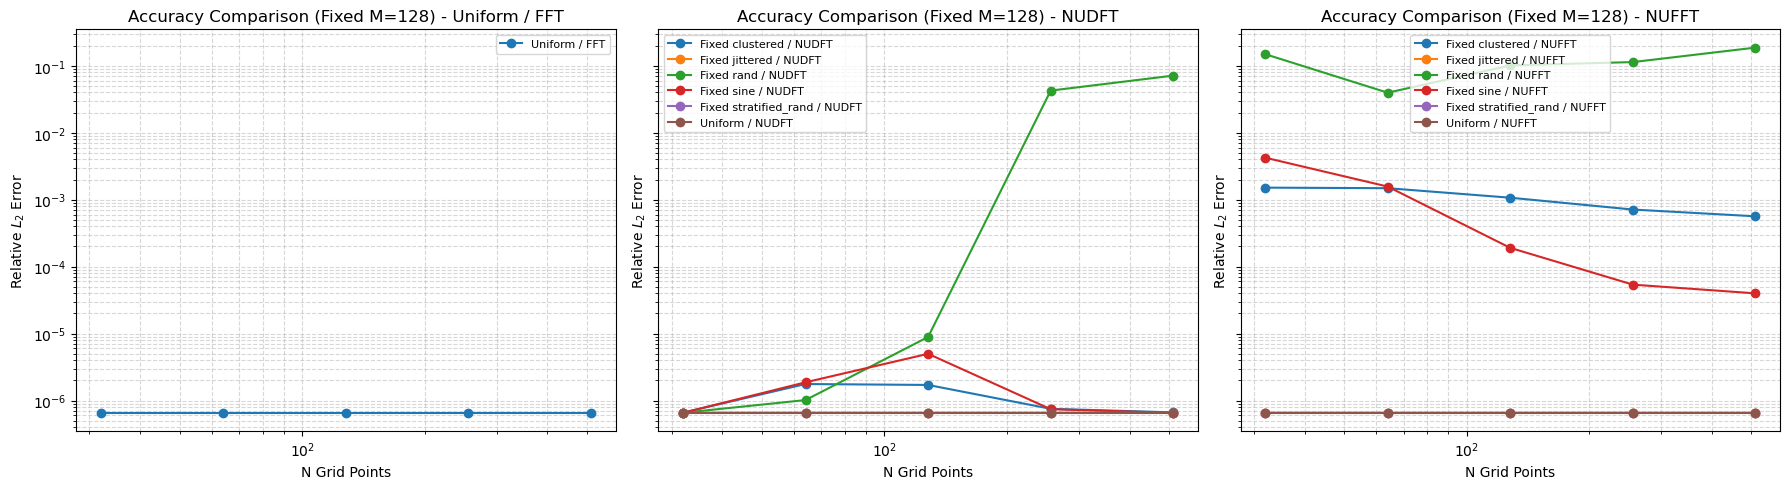

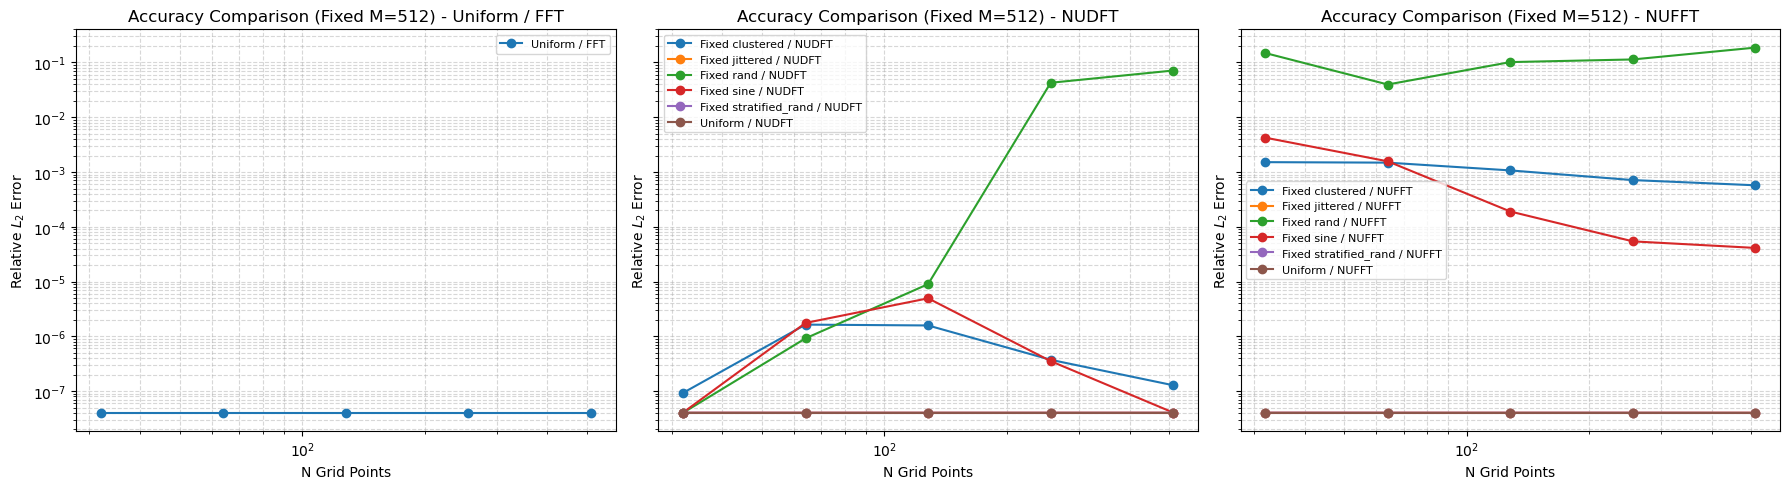

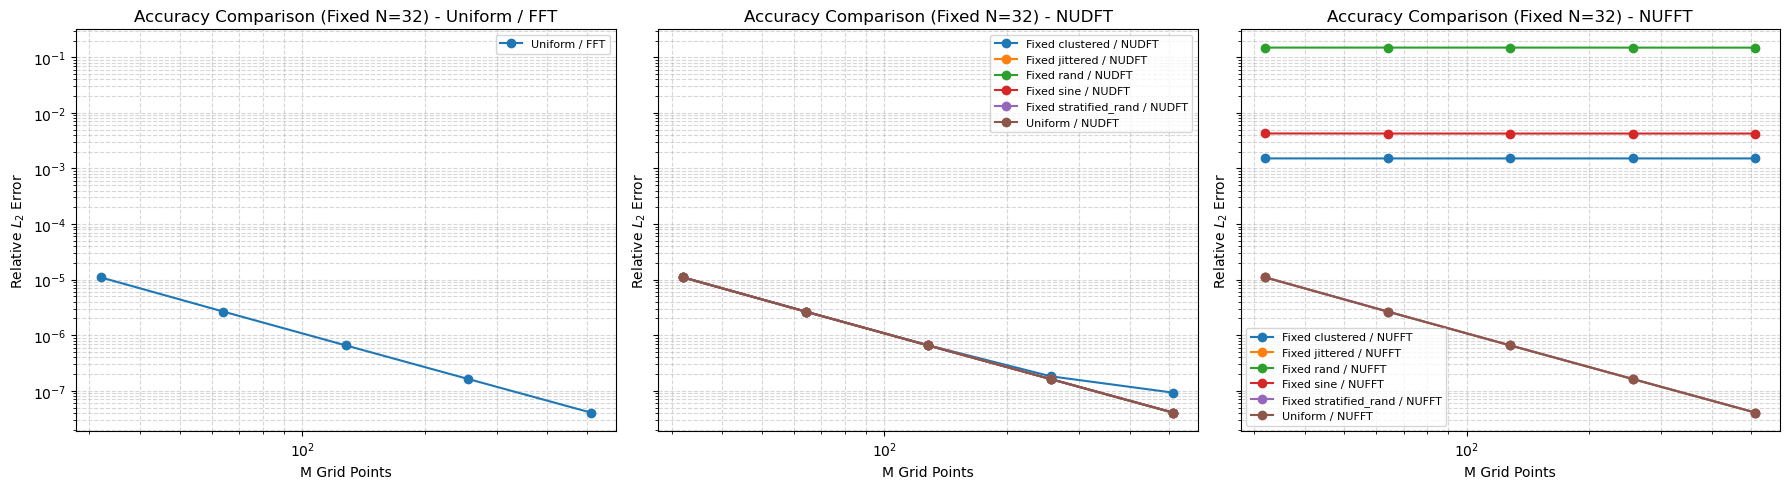

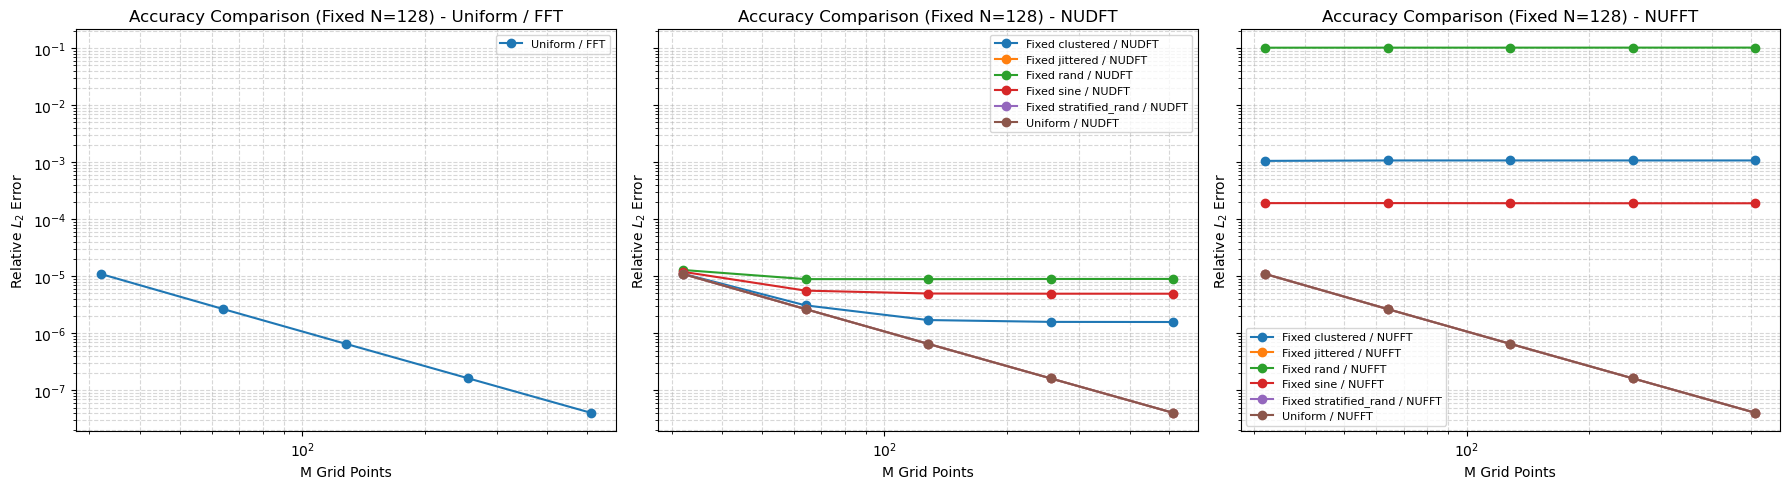

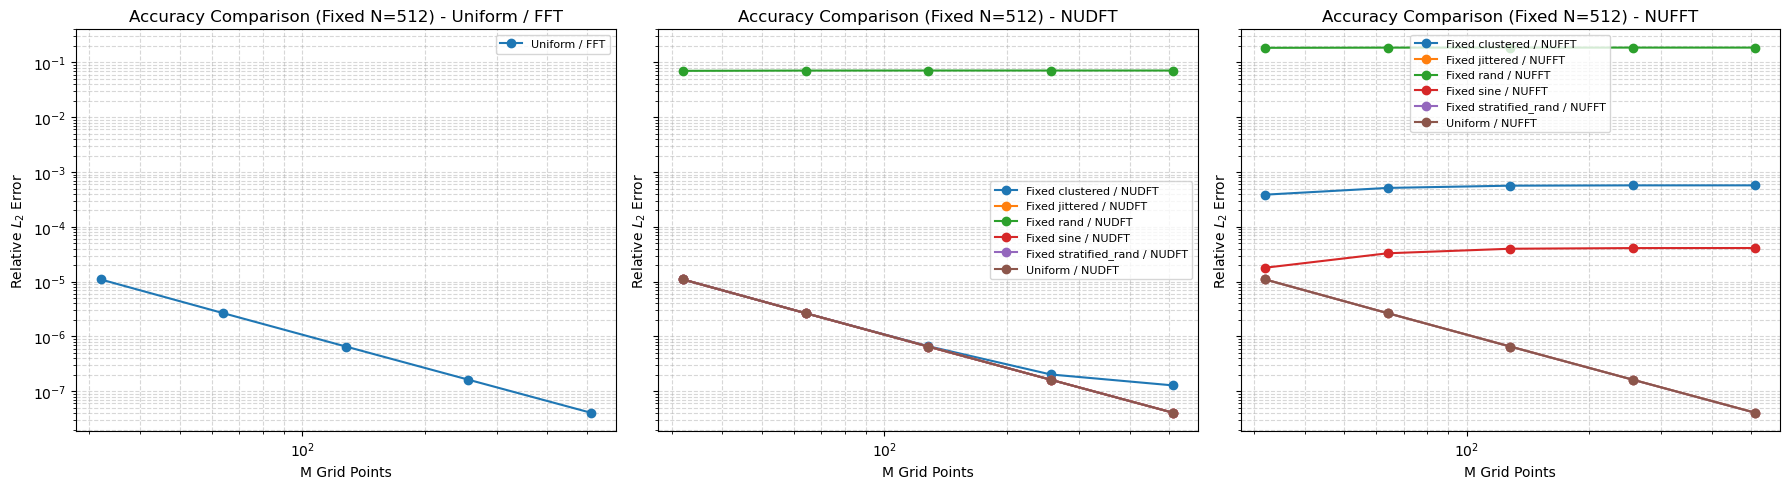


Accuracy Comparison (Fixed M=32) Accuracy


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed clustered / NUDFT,Fixed jittered / NUDFT,Fixed rand / NUDFT,Fixed sine / NUDFT,Fixed stratified_rand / NUDFT,Fixed clustered / NUFFT,Fixed jittered / NUFFT,Fixed rand / NUFFT,Fixed sine / NUFFT,Fixed stratified_rand / NUFFT
N,,,,,,,,,,,,,
32,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.52e-03,1.10e-05,1.49e-01,4.26e-03,1.10e-05
64,1.10e-05,1.10e-05,1.10e-05,1.11e-05,1.10e-05,1.08e-05,1.11e-05,1.10e-05,1.49e-03,1.10e-05,3.96e-02,1.58e-03,1.10e-05
128,1.10e-05,1.10e-05,1.10e-05,1.11e-05,1.10e-05,1.29e-05,1.20e-05,1.10e-05,1.05e-03,1.10e-05,1.01e-01,1.91e-04,1.10e-05
256,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,4.22e-02,1.10e-05,1.10e-05,6.30e-04,1.10e-05,1.13e-01,4.71e-05,1.10e-05
512,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,7.04e-02,1.10e-05,1.10e-05,3.87e-04,1.10e-05,1.85e-01,1.80e-05,1.10e-05



Accuracy Comparison (Fixed M=128) Accuracy


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed clustered / NUDFT,Fixed jittered / NUDFT,Fixed rand / NUDFT,Fixed sine / NUDFT,Fixed stratified_rand / NUDFT,Fixed clustered / NUFFT,Fixed jittered / NUFFT,Fixed rand / NUFFT,Fixed sine / NUFFT,Fixed stratified_rand / NUFFT
N,,,,,,,,,,,,,
32,6.55e-07,6.55e-07,6.55e-07,6.60e-07,6.55e-07,6.56e-07,6.55e-07,6.56e-07,1.51e-03,6.55e-07,1.49e-01,4.24e-03,6.56e-07
64,6.55e-07,6.55e-07,6.55e-07,1.76e-06,6.55e-07,1.02e-06,1.87e-06,6.55e-07,1.48e-03,6.55e-07,3.96e-02,1.57e-03,6.55e-07
128,6.55e-07,6.55e-07,6.55e-07,1.71e-06,6.55e-07,8.90e-06,4.99e-06,6.55e-07,1.07e-03,6.55e-07,1.01e-01,1.91e-04,6.55e-07
256,6.55e-07,6.55e-07,6.55e-07,7.52e-07,6.55e-07,4.26e-02,7.42e-07,6.55e-07,7.12e-04,6.55e-07,1.14e-01,5.38e-05,6.55e-07
512,6.55e-07,6.55e-07,6.55e-07,6.66e-07,6.55e-07,7.13e-02,6.55e-07,6.55e-07,5.65e-04,6.55e-07,1.87e-01,3.99e-05,6.55e-07



Accuracy Comparison (Fixed M=512) Accuracy


...

label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed clustered / NUDFT,Fixed jittered / NUDFT,Fixed rand / NUDFT,Fixed sine / NUDFT,Fixed stratified_rand / NUDFT,Fixed clustered / NUFFT,Fixed jittered / NUFFT,Fixed rand / NUFFT,Fixed sine / NUFFT,Fixed stratified_rand / NUFFT
M,,,,,,,,,,,,,
32,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.52e-03,1.10e-05,1.49e-01,4.26e-03,1.10e-05
64,2.66e-06,2.66e-06,2.66e-06,2.66e-06,2.66e-06,2.67e-06,2.66e-06,2.66e-06,1.51e-03,2.66e-06,1.49e-01,4.25e-03,2.66e-06
128,6.55e-07,6.55e-07,6.55e-07,6.60e-07,6.55e-07,6.56e-07,6.55e-07,6.56e-07,1.51e-03,6.55e-07,1.49e-01,4.24e-03,6.56e-07
256,1.62e-07,1.62e-07,1.62e-07,1.82e-07,1.62e-07,1.62e-07,1.62e-07,1.63e-07,1.51e-03,1.62e-07,1.49e-01,4.24e-03,1.63e-07
512,4.04e-08,4.04e-08,4.04e-08,9.25e-08,4.05e-08,4.01e-08,4.05e-08,4.05e-08,1.51e-03,4.05e-08,1.49e-01,4.24e-03,4.05e-08



Accuracy Comparison (Fixed N=128) Accuracy


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed clustered / NUDFT,Fixed jittered / NUDFT,Fixed rand / NUDFT,Fixed sine / NUDFT,Fixed stratified_rand / NUDFT,Fixed clustered / NUFFT,Fixed jittered / NUFFT,Fixed rand / NUFFT,Fixed sine / NUFFT,Fixed stratified_rand / NUFFT
M,,,,,,,,,,,,,
32,1.10e-05,1.10e-05,1.10e-05,1.11e-05,1.10e-05,1.29e-05,1.20e-05,1.10e-05,1.05e-03,1.10e-05,1.01e-01,1.91e-04,1.10e-05
64,2.66e-06,2.66e-06,2.66e-06,3.09e-06,2.66e-06,8.91e-06,5.60e-06,2.66e-06,1.07e-03,2.66e-06,1.01e-01,1.92e-04,2.66e-06
128,6.55e-07,6.55e-07,6.55e-07,1.71e-06,6.55e-07,8.90e-06,4.99e-06,6.55e-07,1.07e-03,6.55e-07,1.01e-01,1.91e-04,6.55e-07
256,1.62e-07,1.62e-07,1.62e-07,1.59e-06,1.62e-07,8.96e-06,4.95e-06,1.62e-07,1.07e-03,1.62e-07,1.01e-01,1.90e-04,1.62e-07
512,4.04e-08,4.04e-08,4.04e-08,1.58e-06,4.04e-08,8.98e-06,4.95e-06,4.04e-08,1.07e-03,4.04e-08,1.02e-01,1.90e-04,4.05e-08



Accuracy Comparison (Fixed N=512) Accuracy


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed clustered / NUDFT,Fixed jittered / NUDFT,Fixed rand / NUDFT,Fixed sine / NUDFT,Fixed stratified_rand / NUDFT,Fixed clustered / NUFFT,Fixed jittered / NUFFT,Fixed rand / NUFFT,Fixed sine / NUFFT,Fixed stratified_rand / NUFFT
M,,,,,,,,,,,,,
32,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,7.04e-02,1.10e-05,1.10e-05,3.87e-04,1.10e-05,1.85e-01,1.80e-05,1.10e-05
64,2.66e-06,2.66e-06,2.66e-06,2.66e-06,2.66e-06,7.12e-02,2.66e-06,2.66e-06,5.14e-04,2.66e-06,1.87e-01,3.30e-05,2.66e-06
128,6.55e-07,6.55e-07,6.55e-07,6.66e-07,6.55e-07,7.13e-02,6.55e-07,6.55e-07,5.65e-04,6.55e-07,1.87e-01,3.99e-05,6.55e-07
256,1.62e-07,1.62e-07,1.62e-07,2.03e-07,1.62e-07,7.13e-02,1.62e-07,1.62e-07,5.72e-04,1.62e-07,1.87e-01,4.10e-05,1.62e-07
512,4.04e-08,4.04e-08,4.04e-08,1.28e-07,4.04e-08,7.13e-02,4.05e-08,4.04e-08,5.72e-04,4.04e-08,1.87e-01,4.11e-05,4.04e-08


In [3]:
# Accuracy plots for varying N (different fixed M)
for fixed_m, df_cN in df_cN_by_M.items():
    plot_accuracy_comparison(
        df_cN,
        index_col="N",
        title_prefix=f"Accuracy Comparison (Fixed M={fixed_m})",
    )


# Accuracy plots for varying M (different fixed N)
for fixed_n, df_cM in df_cM_by_N.items():
    plot_accuracy_comparison(
        df_cM,
        index_col="M",
        title_prefix=f"Accuracy Comparison (Fixed N={fixed_n})",
    )


for fixed_m, df_cN in df_cN_by_M.items():
    render_accuracy(
        df_cN,
        index_col="N",
        columns_col="label",
        title_prefix=f"Accuracy Comparison (Fixed M={fixed_m})",
    )

# Accuracy plots for varying M (different fixed N)
for fixed_n, df_cM in df_cM_by_N.items():
    render_accuracy(
        df_cM,
        index_col="M",
        columns_col="label",
        title_prefix=f"Accuracy Comparison (Fixed N={fixed_n})",
    )



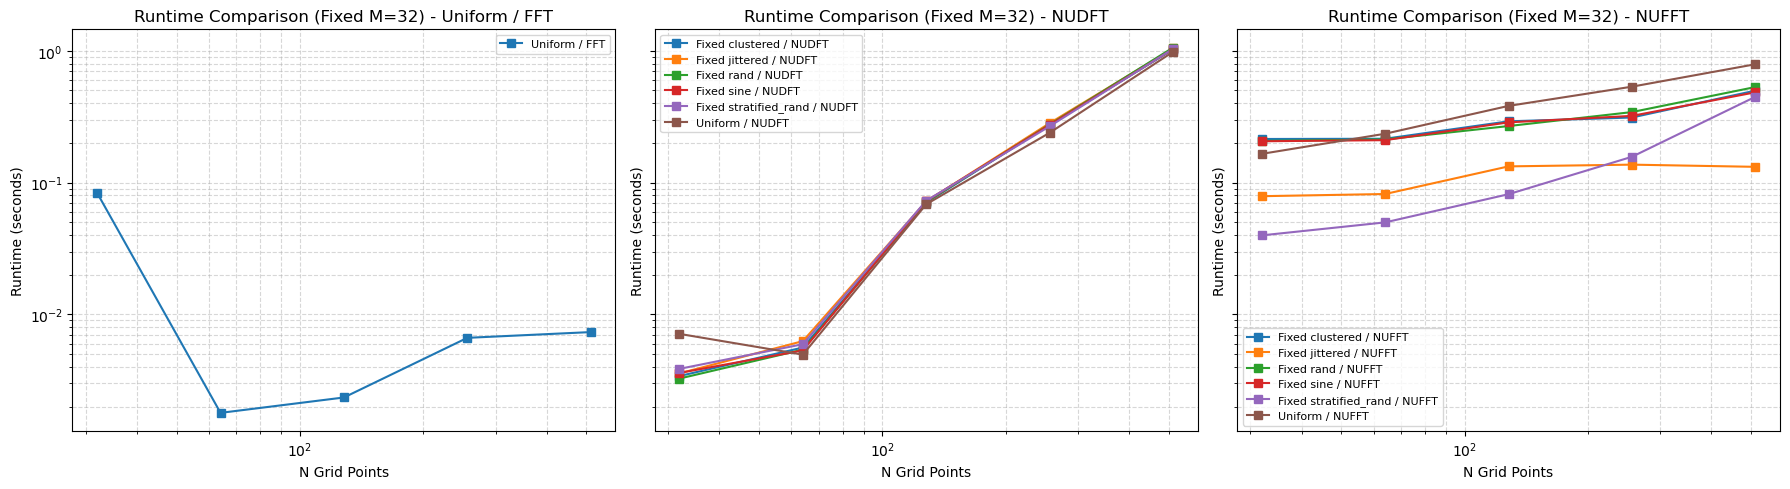

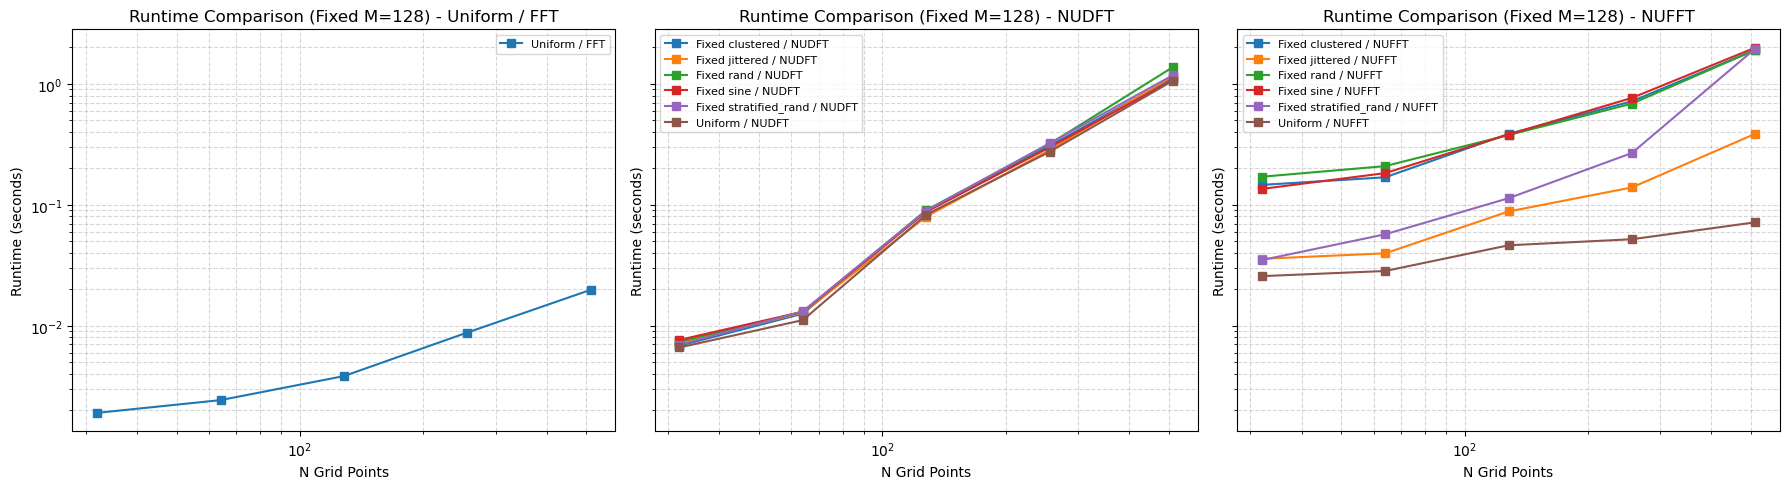

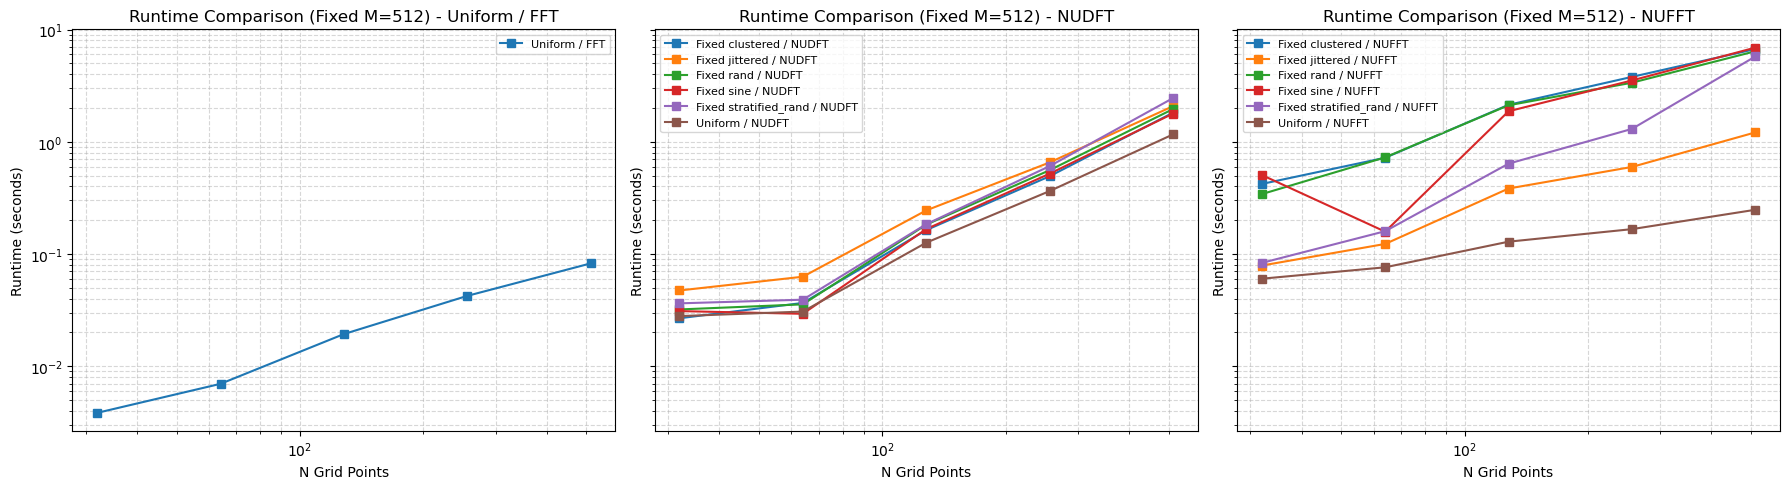

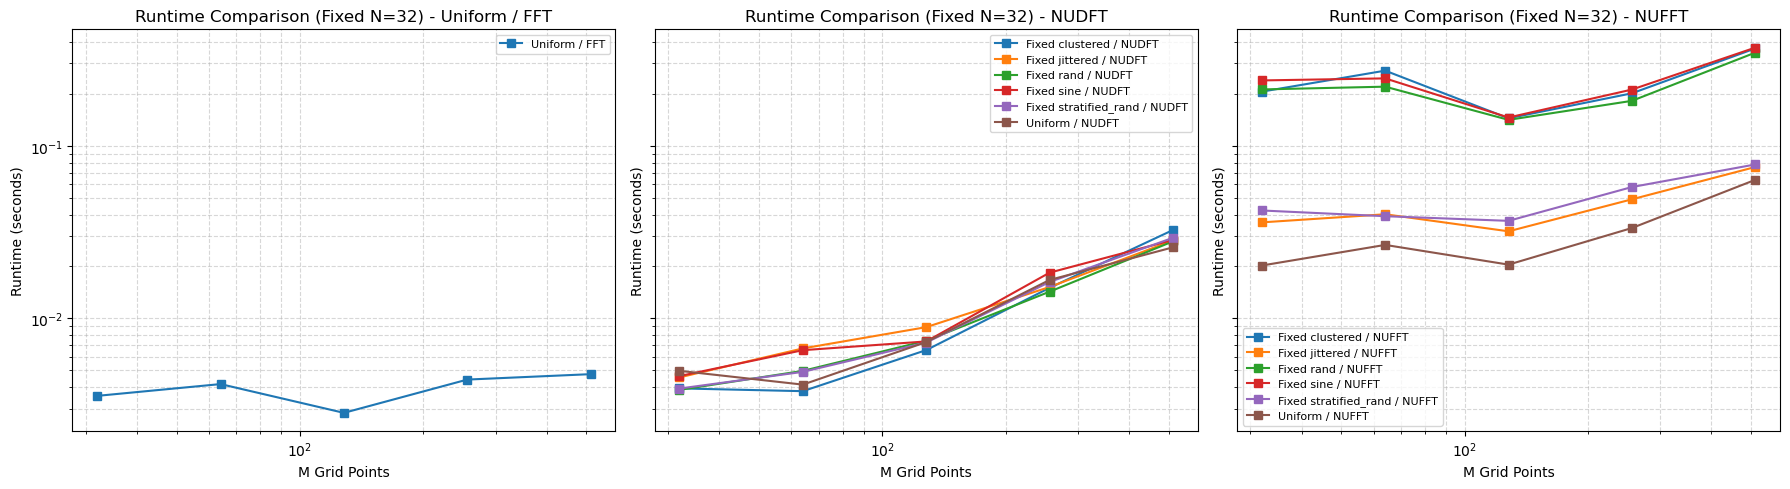

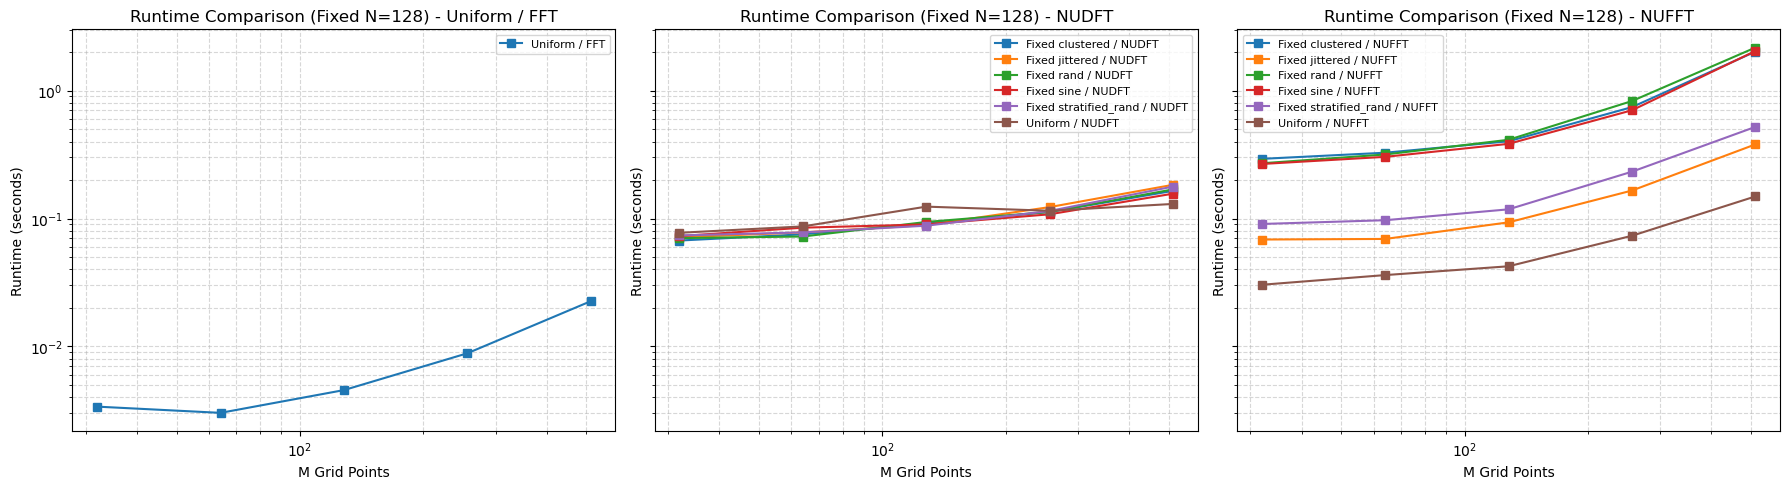

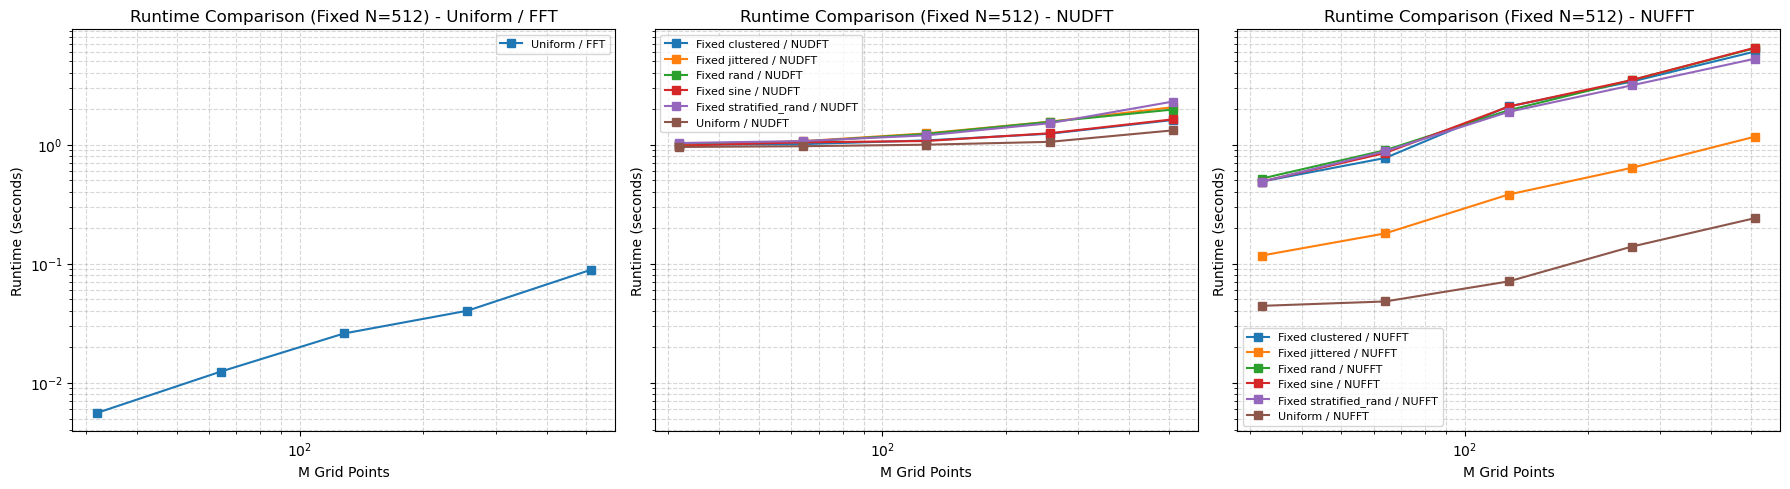

Accuracy Comparison (Fixed M=32) Runtimes

Runtime Comparison (Fixed M=32) Runtime (s)


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed clustered / NUDFT,Fixed jittered / NUDFT,Fixed rand / NUDFT,Fixed sine / NUDFT,Fixed stratified_rand / NUDFT,Fixed clustered / NUFFT,Fixed jittered / NUFFT,Fixed rand / NUFFT,Fixed sine / NUFFT,Fixed stratified_rand / NUFFT
N,,,,,,,,,,,,,
32,0.0834,0.0071,0.1651,0.0034,0.0036,0.0033,0.0036,0.0039,0.2141,0.0788,0.2069,0.2057,0.0398
64,0.0018,0.0050,0.2346,0.0056,0.0063,0.0054,0.0053,0.0059,0.2150,0.0819,0.2125,0.2098,0.0499
128,0.0023,0.0685,0.3816,0.0704,0.0719,0.0713,0.0723,0.0728,0.2915,0.1327,0.2683,0.2863,0.0816
256,0.0066,0.2385,0.5339,0.2748,0.2823,0.2757,0.2735,0.2671,0.3116,0.1368,0.3425,0.3205,0.1569
512,0.0073,0.9814,0.7899,1.0216,1.0401,1.0565,1.0294,1.0336,0.4983,0.1316,0.5305,0.4838,0.4473


Accuracy Comparison (Fixed M=128) Runtimes

Runtime Comparison (Fixed M=128) Runtime (s)


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed clustered / NUDFT,Fixed jittered / NUDFT,Fixed rand / NUDFT,Fixed sine / NUDFT,Fixed stratified_rand / NUDFT,Fixed clustered / NUFFT,Fixed jittered / NUFFT,Fixed rand / NUFFT,Fixed sine / NUFFT,Fixed stratified_rand / NUFFT
N,,,,,,,,,,,,,
32,0.0019,0.0066,0.0257,0.0068,0.0073,0.0074,0.0076,0.0070,0.1460,0.0357,0.1705,0.1352,0.0349
64,0.0024,0.0111,0.0284,0.0126,0.0128,0.0130,0.0131,0.0132,0.1687,0.0397,0.2087,0.1826,0.0570
128,0.0038,0.0829,0.0462,0.0888,0.0799,0.0902,0.0873,0.0892,0.3855,0.0880,0.3771,0.3808,0.1133
256,0.0088,0.2742,0.0519,0.3067,0.2831,0.3183,0.2982,0.3224,0.7165,0.1391,0.6855,0.7644,0.2679
512,0.0198,1.0613,0.0716,1.1219,1.1598,1.3755,1.0790,1.1790,1.9082,0.3865,1.9064,1.9918,1.9565


Accuracy Comparison (Fixed M=512) Runtimes

Runtime Comparison (Fixed M=512) Runtime (s)


...

label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed clustered / NUDFT,Fixed jittered / NUDFT,Fixed rand / NUDFT,Fixed sine / NUDFT,Fixed stratified_rand / NUDFT,Fixed clustered / NUFFT,Fixed jittered / NUFFT,Fixed rand / NUFFT,Fixed sine / NUFFT,Fixed stratified_rand / NUFFT
M,,,,,,,,,,,,,
32,0.0036,0.0050,0.0203,0.0039,0.0046,0.0039,0.0046,0.0039,0.2060,0.0360,0.2121,0.2392,0.0422
64,0.0042,0.0041,0.0267,0.0038,0.0067,0.0050,0.0066,0.0049,0.2725,0.0401,0.2201,0.2458,0.0391
128,0.0028,0.0073,0.0205,0.0066,0.0089,0.0074,0.0074,0.0073,0.1443,0.0320,0.1414,0.1459,0.0368
256,0.0044,0.0167,0.0334,0.0151,0.0152,0.0143,0.0184,0.0163,0.2015,0.0490,0.1822,0.2118,0.0577
512,0.0048,0.0258,0.0635,0.0325,0.0283,0.0280,0.0285,0.0293,0.3666,0.0754,0.3467,0.3706,0.0780


Accuracy Comparison (Fixed N=128) Runtimes

Runtime Comparison (Fixed N=128) Runtime (s)


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed clustered / NUDFT,Fixed jittered / NUDFT,Fixed rand / NUDFT,Fixed sine / NUDFT,Fixed stratified_rand / NUDFT,Fixed clustered / NUFFT,Fixed jittered / NUFFT,Fixed rand / NUFFT,Fixed sine / NUFFT,Fixed stratified_rand / NUFFT
M,,,,,,,,,,,,,
32,0.0034,0.0773,0.0303,0.0673,0.0713,0.0703,0.0729,0.0738,0.2927,0.0685,0.2702,0.2669,0.0906
64,0.0030,0.0867,0.0361,0.0753,0.0779,0.0723,0.0848,0.0779,0.3269,0.0692,0.3166,0.3035,0.0970
128,0.0046,0.1238,0.0423,0.0915,0.0888,0.0940,0.0899,0.0879,0.4016,0.0933,0.4125,0.3835,0.1180
256,0.0088,0.1150,0.0733,0.1125,0.1228,0.1127,0.1079,0.1145,0.7426,0.1654,0.8284,0.7017,0.2322
512,0.0226,0.1300,0.1488,0.1645,0.1834,0.1689,0.1564,0.1777,2.0168,0.3796,2.1686,2.0381,0.5202


Accuracy Comparison (Fixed N=512) Runtimes

Runtime Comparison (Fixed N=512) Runtime (s)


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed clustered / NUDFT,Fixed jittered / NUDFT,Fixed rand / NUDFT,Fixed sine / NUDFT,Fixed stratified_rand / NUDFT,Fixed clustered / NUFFT,Fixed jittered / NUFFT,Fixed rand / NUFFT,Fixed sine / NUFFT,Fixed stratified_rand / NUFFT
M,,,,,,,,,,,,,
32,0.0056,0.9537,0.0442,0.9959,0.9880,1.0164,0.9792,1.0292,0.4889,0.1169,0.5180,0.4892,0.4872
64,0.0124,0.9682,0.0481,1.0078,1.0673,1.0573,1.0442,1.0697,0.7712,0.1793,0.8958,0.8492,0.8789
128,0.0259,0.9969,0.0708,1.0830,1.2402,1.2277,1.0702,1.1941,2.0909,0.3802,1.9388,2.0811,1.8803
256,0.0402,1.0532,0.1390,1.2327,1.5542,1.5515,1.2437,1.5095,3.3795,0.6376,3.4780,3.4805,3.1458
512,0.0886,1.3151,0.2413,1.6071,2.0589,1.9683,1.6282,2.2968,6.0524,1.1664,6.4571,6.5182,5.2655


In [4]:
# Runtime plots/tables for varying N
for fixed_m, df_cN in df_cN_by_M.items():
    plot_runtime_comparison(
        df_cN,
        index_col="N",
        title_prefix=f"Runtime Comparison (Fixed M={fixed_m})",
    )


# Runtime plots/tables for varying M
for fixed_n, df_cM in df_cM_by_N.items():
    plot_runtime_comparison(
        df_cM,
        index_col="M",
        title_prefix=f"Runtime Comparison (Fixed N={fixed_n})",
    )


# Runtime plots/tables for varying N
for fixed_m, df_cN in df_cN_by_M.items():

    print(f"Accuracy Comparison (Fixed M={fixed_m}) Runtimes")
    render_runtime(
        df_cN,
        index_col="N",
        columns_col="label",
        title_prefix=f"Runtime Comparison (Fixed M={fixed_m})",
    )

# Runtime plots/tables for varying M
for fixed_n, df_cM in df_cM_by_N.items():
    print(f"Accuracy Comparison (Fixed N={fixed_n}) Runtimes")
    render_runtime(
        df_cM,
        index_col="M",
        columns_col="label",
        title_prefix=f"Runtime Comparison (Fixed N={fixed_n})",
    )